In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs

from unseen import eva
from unseen import fileio

import utils

In [3]:
#import importlib

In [4]:
#importlib.reload(utils)

In [5]:
# optional parameters
# (this cell is tagged "parameters")

metric = 'txx'
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}  

In [6]:
assert "metric" in locals(), "Must provide a metric (rx1day or txx)"
assert "model_dict" in locals(), "Must provide a model dict"

In [7]:
def extract_closest_row(df, return_period):
    """Extract the row from df closest to the return period."""

    differences = np.array(np.abs(return_df.index - 100))
    index = np.argmin(differences)

    return df.iloc[index]

In [10]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

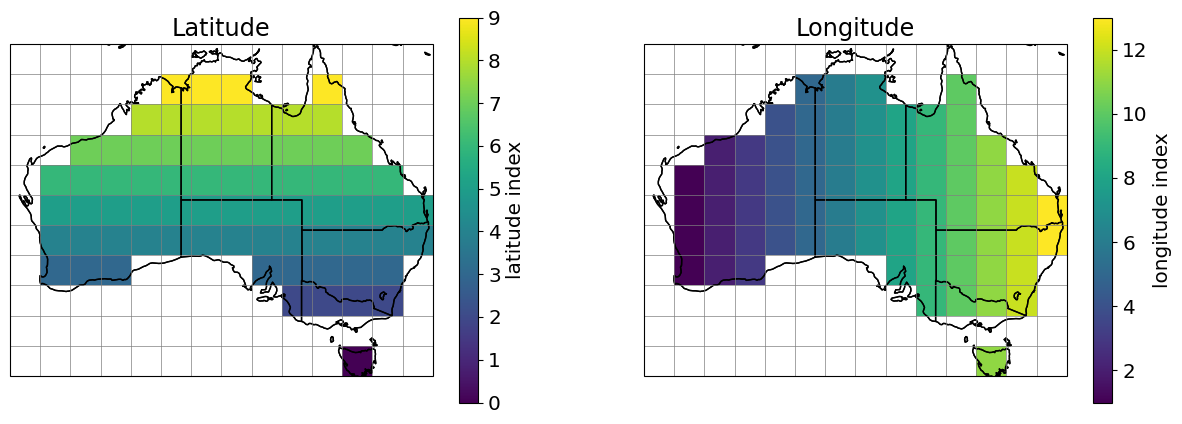

In [11]:
lon_array = xr.DataArray(
#    data=np.tile(mask.lon, (11, 1)),
    data=np.tile(np.arange(0,14), (11, 1)),
    coords={'lat': mask.lat, 'lon': mask.lon},
)

lat_array = xr.DataArray(
#    data=np.squeeze(np.dstack([mask.lat]*14)),
    data=np.squeeze(np.dstack([np.arange(0,11)]*14)),
    coords={'lat': mask.lat, 'lon': mask.lon},
) 

min_lat = mask.lat.values.min() - 1.5
max_lat = mask.lat.values.max() + 1.5
min_lon = mask.lon.values.min() - 1.5
max_lon = mask.lon.values.max() + 1.5

fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = lat_array.where(mask).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'latitude index'},
)
ax1.set_title('Latitude')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = lon_array.where(mask).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'longitude index'},
)
ax2.set_title('Longitude')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

for lon in mask.lon.values:
    ax1.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
for lat in mask.lat.values:
    ax1.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)

plt.show()

In [12]:
mask = mask.isel(lat=slice(0,3))

In [15]:
return_periods = np.array([100, 1000])
nlevels = len(return_periods)
nlats, nlons = mask.shape
G_array = np.zeros([nlevels, nlats, nlons])
M_array = np.zeros([nlevels, nlats, nlons])
B_array = np.zeros([nlevels, nlats, nlons])
T_array = np.zeros([nlevels, nlats, nlons])
O_array = np.zeros([nlevels, nlats, nlons])
MMM_array = np.zeros([nlevels, nlats, nlons])
obs_array = np.zeros([nlevels, nlats, nlons])
nmodels_array = np.zeros([nlats, nlons])
for lat_index in range(nlats):
    for lon_index in range(nlons):
        print(lat_index, lon_index)
        include_point = mask.isel({'lat': lat_index, 'lon': lon_index})
        if include_point:
            return_df, gev_spread_df = utils.get_return_values(metric, [lat_index, lon_index], model_dict, similarity_check=True)
            nmodels = return_df.filter(like='model-bc-mean').shape[1]
            obs, MMM, uncertainty = utils.uncertainty_breakdown(return_df, gev_spread_df)
            G, M, B, T, O = uncertainty
            for level_index, return_period in enumerate(return_periods):
                Gs = extract_closest_row(G, return_period)
                Ms = extract_closest_row(M, return_period)
                Bs = extract_closest_row(B, return_period)
                Ts = extract_closest_row(T, return_period)
                Os = extract_closest_row(O, return_period)
                MMMs = extract_closest_row(MMM, return_period)
                obss = extract_closest_row(obs, return_period)
                GMBs = Gs + Ms + Bs
                Gs_pct = (Gs / GMBs) * 100
                Ms_pct = (Ms / GMBs) * 100
                Bs_pct = (Bs / GMBs) * 100
                G_array[level_index, lat_index, lon_index] = Gs_pct
                M_array[level_index, lat_index, lon_index] = Ms_pct
                B_array[level_index, lat_index, lon_index] = Bs_pct
                T_array[level_index, lat_index, lon_index] = Ts
                O_array[level_index, lat_index, lon_index] = Os
                MMM_array[level_index, lat_index, lon_index] = MMMs
                obs_array[level_index, lat_index, lon_index] = obss
                nmodels_array[lat_index, lon_index] = nmodels
        else:
            for level_index in range(nlevels):
                G_array[level_index, lat_index, lon_index] = np.nan
                M_array[level_index, lat_index, lon_index] = np.nan
                B_array[level_index, lat_index, lon_index] = np.nan
                T_array[level_index, lat_index, lon_index] = np.nan
                O_array[level_index, lat_index, lon_index] = np.nan
                MMM_array[level_index, lat_index, lon_index] = np.nan
                obs_array[level_index, lat_index, lon_index] = np.nan
                nmodels_array[lat_index, lon_index] = np.nan

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
start: BCC-CSM2-MR
end: BCC-CSM2-MR
start: CAFE
end: CAFE
start: CMCC-CM2-SR5
end: CMCC-CM2-SR5
start: CanESM5
end: CanESM5
start: EC-Earth3
end: EC-Earth3
start: IPSL-CM6A-LR
end: IPSL-CM6A-LR
start: MIROC6
end: MIROC6
start: MPI-ESM1-2-HR
end: MPI-ESM1-2-HR
start: MRI-ESM2-0
end: MRI-ESM2-0
start: NorCPM1
0 12
0 13
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
start: BCC-CSM2-MR
end: BCC-CSM2-MR
start: CAFE
end: CAFE
start: CMCC-CM2-SR5
end: CMCC-CM2-SR5
start: CanESM5
end: CanESM5
start: EC-Earth3
end: EC-Earth3
start: IPSL-CM6A-LR
end: IPSL-CM6A-LR
start: MIROC6
end: MIROC6
start: MPI-ESM1-2-HR
end: MPI-ESM1-2-HR
start: MRI-ESM2-0
end: MRI-ESM2-0
start: NorCPM1
end: NorCPM1
2 10
start: BCC-CSM2-MR
end: BCC-CSM2-MR
start: CAFE
start: CMCC-CM2-SR5
end: CMCC-CM2-SR5
start: CanESM5
end: CanESM5
start: EC-Earth3
end: EC-Earth3
start: IPSL-CM6A-LR
end: IPSL-CM6A-LR
start: MIROC6
end: M

In [16]:
units_dict = {'txx': 'Celsius', 'rx1day': 'mm'}
units = units_dict[metric]
ds_out = xr.Dataset(
    data_vars={
        'G': (['lev', 'lat', 'lon'], G_array, {'long_name': 'GEV uncertainty fraction (model)', 'units': '%'}),
        'M': (['lev', 'lat', 'lon'], M_array, {'long_name': 'model uncertainty fraction (model)', 'units': '%'}),
        'B': (['lev', 'lat', 'lon'], B_array, {'long_name': 'bias correction uncertainty fraction (model)', 'units': '%'}),
        'T': (['lev', 'lat', 'lon'], T_array, {'long_name': 'total model uncertainty (standard deviation)', 'units': units}),
        'O': (['lev', 'lat', 'lon'], O_array, {'long_name': 'total observations uncertainty (standard deviation)', 'units': units}),
        'MMM': (['lev', 'lat', 'lon'], MMM_array, {'long_name': 'multi-model mean (mean correction)', 'units': units}),
        'obs': (['lev', 'lat', 'lon'], obs_array, {'long_name': 'observations', 'units': units}),
        'nmodels': (['lat', 'lon'], nmodels_array, {'long_name': 'number of models', 'units': ' '}),
    },
    coords={
        'lev': (['lev',], return_periods, {'standard_name': 'return_period', 'long_name': 'return period', 'units': 'years'}),
        'lat': (['lat',], mask.lat.values, {'standard_name': 'latitude', 'long_name': 'latitude', 'units': 'degrees_north', 'axis': 'Y'}),
        'lon': (['lon',], mask.lon.values, {'standard_name': 'longitude', 'long_name': 'longitude', 'units': 'degrees_east', 'axis': 'X'}),
    },
    attrs={
        'metric': metric,
    },
)

In [17]:
ds_out

<xarray.Dataset> Size: 5kB
Dimensions:  (lev: 2, lat: 3, lon: 14)
Coordinates:
  * lev      (lev) int64 16B 100 1000
  * lat      (lat) float64 24B -42.0 -39.0 -36.0
  * lon      (lon) float64 112B 113.5 116.5 119.5 122.5 ... 146.5 149.5 152.5
Data variables:
    G        (lev, lat, lon) float64 672B nan nan nan nan ... 11.57 2.974 nan
    M        (lev, lat, lon) float64 672B nan nan nan nan ... 42.22 56.24 nan
    B        (lev, lat, lon) float64 672B nan nan nan nan ... 46.21 40.78 nan
    T        (lev, lat, lon) float64 672B nan nan nan nan ... 0.5576 1.008 nan
    O        (lev, lat, lon) float64 672B nan nan nan nan ... 0.2286 0.37 nan
    MMM      (lev, lat, lon) float64 672B nan nan nan nan ... 43.97 38.78 nan
    obs      (lev, lat, lon) float64 672B nan nan nan nan ... 43.16 39.85 nan
    nmodels  (lat, lon) float64 336B nan nan nan nan nan ... 9.0 6.0 8.0 nan
Attributes:
    metric:   txx

In [18]:
ds_out.to_netcdf(f'{metric}_spatial.nc')